In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [15]:
df = pd.read_csv("/content/BankNote_Authentication.csv")

In [16]:
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [17]:
df.shape

(1372, 5)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [19]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [20]:
X = df.drop(columns ="class", axis = 1)
y = df['class']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [22]:
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [23]:
model = Sequential([Input(shape=(4,)),
                    Dense(16, activation = 'relu'),
                    Dense(8, activation = 'relu'),
                    Dense(1, activation = 'sigmoid')
])

In [24]:
model.compile(loss = 'binary_crossentropy',
                        optimizer ='adam',
                        metrics = ['accuracy'])

In [25]:
history = model.fit(X_train, y_train, epochs = 30, validation_split = 0.2)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5724 - loss: 0.6777 - val_accuracy: 0.5773 - val_loss: 0.6464
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6180 - loss: 0.5926 - val_accuracy: 0.6045 - val_loss: 0.5731
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6659 - loss: 0.5267 - val_accuracy: 0.7455 - val_loss: 0.5182
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8027 - loss: 0.4775 - val_accuracy: 0.8636 - val_loss: 0.4742
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8962 - loss: 0.4355 - val_accuracy: 0.9136 - val_loss: 0.4339
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9282 - loss: 0.3948 - val_accuracy: 0.9364 - val_loss: 0.3917
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9418 - loss: 0.3531 - val_accuracy: 0.9364 - val_loss: 0.3485
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9453 - loss: 0.3115 - val_accuracy: 0.9409 - val_lo

In [26]:
loss, acc = model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0232 


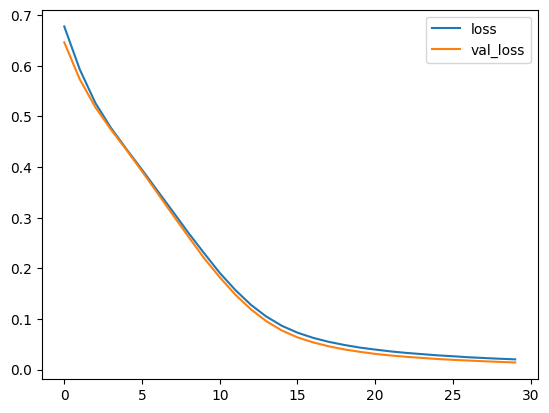

In [29]:
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

Forward propagation passes the input features through each neural-network layer to calculate the final prediction, and the loss function measures how far that prediction is from the actual label. Backpropagation works backward through the network to calculate how much each weight contributed to the error, and the Adam optimizer uses those gradients to update the weights. This process repeats for each batch during every epoch so the model gradually improves its predictions.

Architecture:
Dense(16, ReLU) → Dense(8, ReLU) → Dense(1, Sigmoid)

Optimizer: Adam
Loss: Binary Crossentropy
Epochs: 30
Train/Test Split: 80/20

Test Accuracy:1.0